In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from imblearn.over_sampling import RandomOverSampler 

In [2]:
df = pd.read_csv("data.csv")
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


- id: Unique ID for the customer
- Gender: Gender of the customer
- Age: Age of the customer
- Driving_License: [0 : Customer does not have DL, 1 : Customer already has DL]
- Region_Code: Unique code for the region of the customer
- Previously_Insured: [1 : Customer already has Vehicle Insurance, 0 : Customer doesn't have Vehicle Insurance]
- Vehicle_Age: Age of the Vehicle
- Vehicle_Damage: [1 : Customer got his/her vehicle damaged in the past. 0 : Customer didn't get his/her vehicle damaged in the past.]
- Annual_Premium: The amount customer needs to pay as premium in the year
- Policy_Sales_Channel: Anonymized Code for the channel of outreaching to the customer ie. Different Agents, Over Mail, Over Phone, In Person, etc.
- Vintage: Number of Days, Customer has been associated with the company
- Response: [1 : Customer is interested, 0 : Customer is not interested]

# EDA

In [3]:
df.shape

(381109, 12)

In [4]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [6]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [7]:
df["Response"].value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

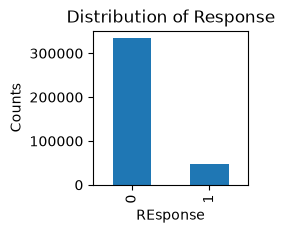

In [8]:
value_counts = df["Response"].value_counts()

plt.figure(figsize=(2,2))

value_counts.plot(kind="bar")
plt.xlabel("REsponse")
plt.ylabel("Counts")
plt.title("Distribution of Response")

plt.show()

<Axes: >

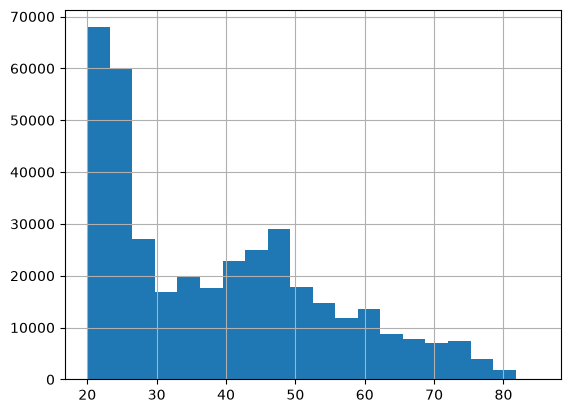

In [9]:
df["Age"].hist(bins=20)

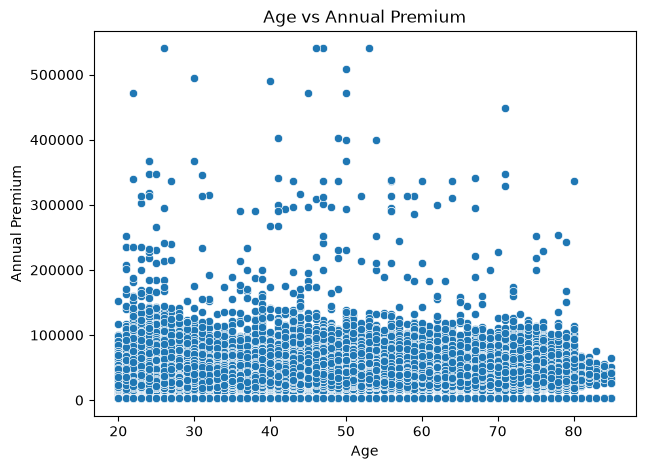

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="Age", y="Annual_Premium", data=df)
plt.xlabel("Age")
plt.ylabel("Annual Premium")
plt.title("Age vs Annual Premium")

plt.show()

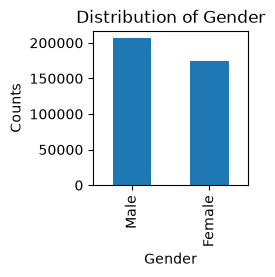

In [11]:
value_counts = df["Gender"].value_counts()
plt.figure(figsize=(2,2))

value_counts.plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Counts")
plt.title("Distribution of Gender")
plt.show()

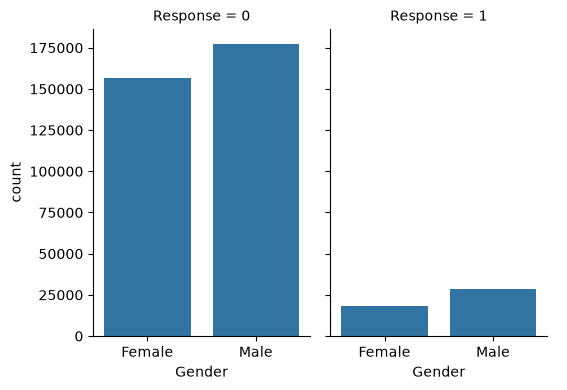

In [12]:
data = df.groupby(["Gender", "Response"])["id"].count().to_frame().rename(columns={"id":"count"}).reset_index()
sns.catplot(x="Gender", y="count", col="Response", data=data, kind="bar", height=4, aspect=.7)

In [13]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='str')

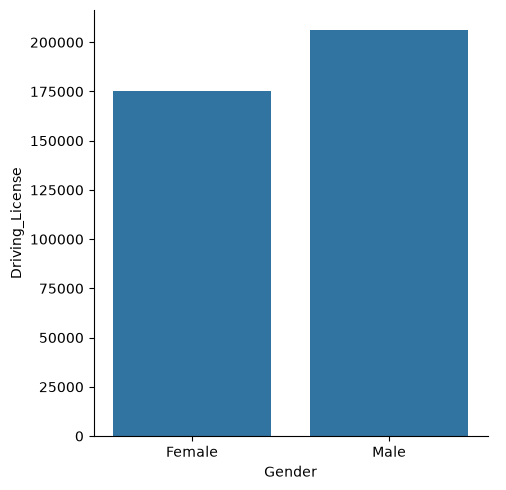

In [14]:
# driving license by gender 
data = df.groupby(["Gender"])["Driving_License"].count().to_frame().reset_index()
sns.catplot(x="Gender", y="Driving_License", kind="bar", data=data)

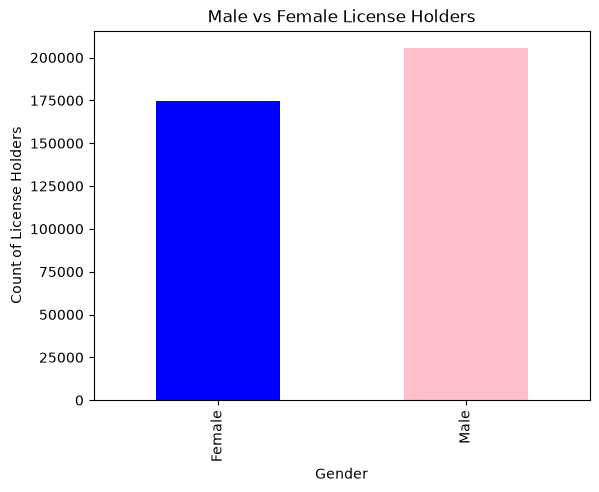

In [15]:
df[df["Driving_License"]==1].groupby(["Gender"]).size().plot(kind="bar", color=["blue", "pink"])

# plt.figure(figsize=(5,5))
plt.xlabel("Gender")
plt.ylabel("Count of License Holders")
plt.title("Male vs Female License Holders")

plt.show()

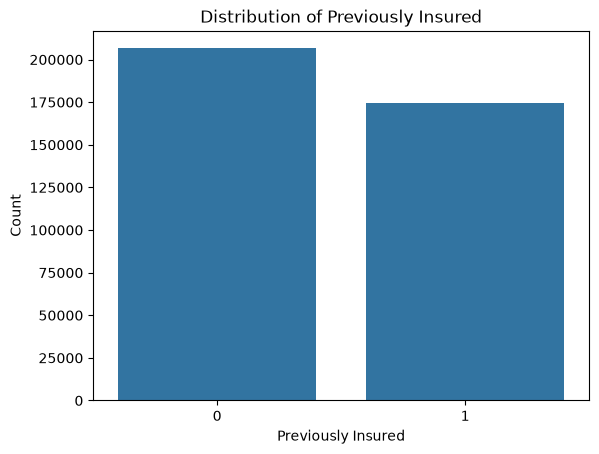

In [16]:
sns.countplot(x="Previously_Insured", data=df)
plt.title("Distribution of Previously Insured")
plt.xlabel("Previously Insured")
plt.ylabel("Count")
plt.show()

In [17]:
df.columns

Index(['id', 'Gender', 'Age', 'Driving_License', 'Region_Code',
       'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Response'],
      dtype='str')

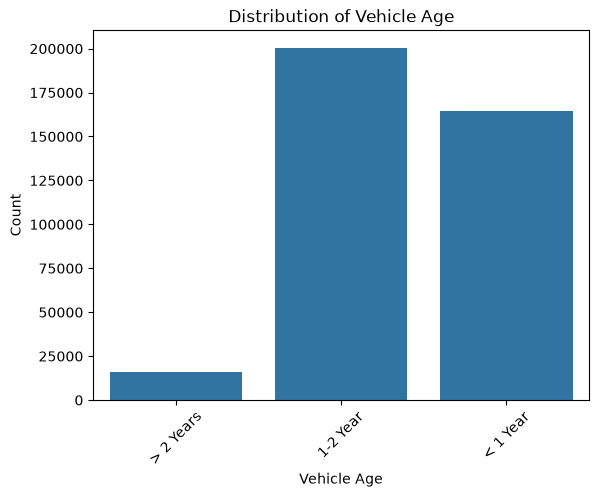

In [18]:
sns.countplot(x="Vehicle_Age", data=df)
plt.xlabel('Vehicle Age')
plt.ylabel('Count')
plt.title('Distribution of Vehicle Age')
plt.xticks(rotation=45)  # Rotate x-axis labels if they overlap
plt.show()

In [19]:
df.groupby(["Vehicle_Age", "Response"])["id"].count()

Vehicle_Age  Response
1-2 Year     0           165510
             1            34806
< 1 Year     0           157584
             1             7202
> 2 Years    0            11305
             1             4702
Name: id, dtype: int64

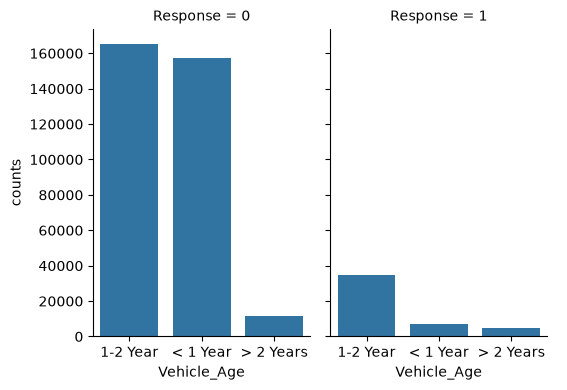

In [20]:
data = df.groupby(["Vehicle_Age", "Response"])["id"].count().to_frame().rename(columns={"id":"counts"}).reset_index()
sns.catplot(x="Vehicle_Age", y="counts", col="Response", data=data, kind="bar", height=4, aspect=.7)

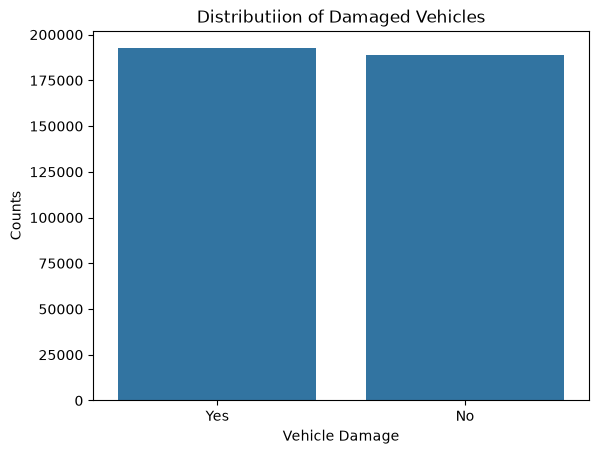

In [21]:
sns.countplot(x="Vehicle_Damage", data=df)
plt.xlabel("Vehicle Damage")
plt.ylabel("Counts")
plt.title("Distributiion of Damaged Vehicles")
plt.show()

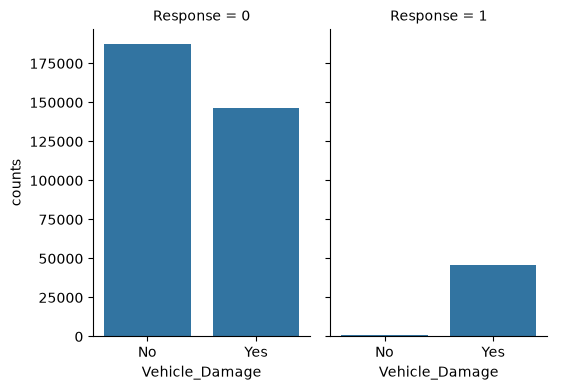

In [22]:
data = df.groupby(["Vehicle_Damage", "Response"])["id"].count().to_frame().rename(columns={"id":"counts"}).reset_index()

sns.catplot(x="Vehicle_Damage", y="counts", col="Response", data=data, kind="bar", height=4, aspect=.7)

In [23]:
df["Annual_Premium"].describe()

count    381109.000000
mean      30564.389581
std       17213.155057
min        2630.000000
25%       24405.000000
50%       31669.000000
75%       39400.000000
max      540165.000000
Name: Annual_Premium, dtype: float64

<Axes: >

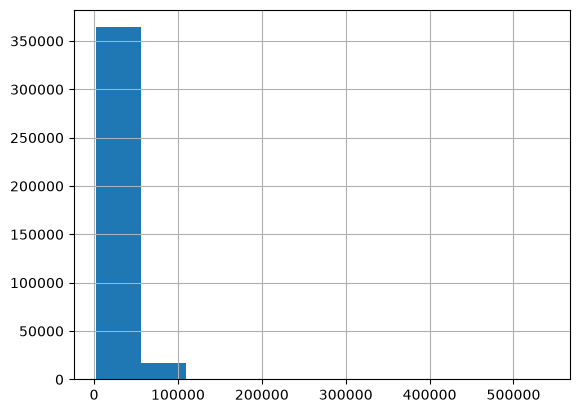

In [24]:
df["Annual_Premium"].hist(bins=10)

In [25]:
df[df["Annual_Premium"]>200000]

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
1412,1413,Female,41,1,28.0,0,1-2 Year,Yes,267698.0,124.0,63,1
11319,11320,Female,50,1,46.0,1,1-2 Year,No,508073.0,26.0,192,0
13426,13427,Female,47,1,28.0,0,1-2 Year,Yes,301762.0,124.0,22,0
15024,15025,Female,32,1,28.0,0,1-2 Year,Yes,315565.0,155.0,150,0
25532,25533,Male,50,1,28.0,0,1-2 Year,Yes,229935.0,122.0,64,1
...,...,...,...,...,...,...,...,...,...,...,...,...
368263,368264,Female,25,1,28.0,1,< 1 Year,Yes,346982.0,124.0,74,0
371910,371911,Female,23,1,37.0,1,< 1 Year,No,235683.0,152.0,246,0
372492,372493,Male,46,1,18.0,0,1-2 Year,No,220581.0,26.0,210,0
373415,373416,Male,56,1,28.0,0,1-2 Year,No,337573.0,26.0,239,0


### Data Preprocessing

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [27]:
df["Gender"]. value_counts()

Gender
Male      206089
Female    175020
Name: count, dtype: int64

In [28]:
df["Gender"] = df["Gender"].map({"Female":0, "Male": 1}).astype(int)
df.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,1,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,1,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0


In [29]:
# for col in df.columns:
#     print(f"{col} >> {df[col].dtype}")
df.dtypes

id                        int64
Gender                    int64
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age                 str
Vehicle_Damage              str
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [30]:
# creating dummy cols for categorical features 
df = pd.get_dummies(df, drop_first=True)
df.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_< 1 Year,Vehicle_Age_> 2 Years,Vehicle_Damage_Yes
0,1,1,44,1,28.0,0,40454.0,26.0,217,1,False,True,True
1,2,1,76,1,3.0,0,33536.0,26.0,183,0,False,False,False


In [31]:
df.dtypes

id                         int64
Gender                     int64
Age                        int64
Driving_License            int64
Region_Code              float64
Previously_Insured         int64
Annual_Premium           float64
Policy_Sales_Channel     float64
Vintage                    int64
Response                   int64
Vehicle_Age_< 1 Year        bool
Vehicle_Age_> 2 Years       bool
Vehicle_Damage_Yes          bool
dtype: object

In [32]:
df = df.rename(columns={"Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year", 
                        "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"})

df["Vehicle_Age_lt_1_Year"] = df["Vehicle_Age_lt_1_Year"].astype(int)
df["Vehicle_Age_gt_2_Years"] = df["Vehicle_Age_gt_2_Years"].astype(int)
df["Vehicle_Damage_Yes"] = df["Vehicle_Damage_Yes"].astype(int)

In [33]:
df.dtypes

id                          int64
Gender                      int64
Age                         int64
Driving_License             int64
Region_Code               float64
Previously_Insured          int64
Annual_Premium            float64
Policy_Sales_Channel      float64
Vintage                     int64
Response                    int64
Vehicle_Age_lt_1_Year       int64
Vehicle_Age_gt_2_Years      int64
Vehicle_Damage_Yes          int64
dtype: object

In [34]:
num_feat = ["Age", "Vintage"]
cat_feat = ['Gender', 'Driving_License', 'Region_Code','Previously_Insured', 
            'Vehicle_Age_lt_1_Year', 'Vehicle_Age_gt_2_Years', 'Vehicle_Damage_Yes', 'Policy_Sales_Channel']

In [35]:
df.dtypes

id                          int64
Gender                      int64
Age                         int64
Driving_License             int64
Region_Code               float64
Previously_Insured          int64
Annual_Premium            float64
Policy_Sales_Channel      float64
Vintage                     int64
Response                    int64
Vehicle_Age_lt_1_Year       int64
Vehicle_Age_gt_2_Years      int64
Vehicle_Damage_Yes          int64
dtype: object

In [36]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

ss = StandardScaler()
df[num_feat] = ss.fit_transform(df[num_feat])

mm = MinMaxScaler()
df[["Annual_Premium"]] = mm.fit_transform(df[["Annual_Premium"]])

df = df.drop("id", axis=1)

In [37]:
df.head()

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Vehicle_Age_lt_1_Year,Vehicle_Age_gt_2_Years,Vehicle_Damage_Yes
0,1,0.333777,1,28.0,0,0.070366,26.0,0.748795,1,0,1,1
1,1,2.396751,1,3.0,0,0.057496,26.0,0.342443,0,0,0,0
2,1,0.527181,1,28.0,0,0.066347,26.0,-1.521998,1,0,1,1
3,1,-1.148985,1,11.0,1,0.048348,152.0,0.581474,0,1,0,0
4,0,-0.633242,1,41.0,1,0.046259,152.0,-1.378580,0,1,0,0


In [38]:
from sklearn.model_selection import train_test_split

y = df["Response"]
X = df.drop(["Response"], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [39]:
y

0         1
1         0
2         1
3         0
4         0
         ..
381104    0
381105    0
381106    0
381107    0
381108    0
Name: Response, Length: 381109, dtype: int64

In [40]:
X_train.shape

(285831, 11)

In [41]:
X_test.shape

(95278, 11)

## Model Trainer - Random Forest Classifier 

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

random_search = {"criterion": ["entropy", "gini"],
                 "max_depth": [2,3,4,5,6,7,10],
                 "min_samples_leaf": [4,6,8], 
                 "min_samples_split": [5,7,10],
                 "n_estimators":[300]}

clf = RandomForestClassifier()
model = RandomizedSearchCV(estimator=clf, param_distributions=random_search, n_iter=10, 
                           cv=4, verbose=1, random_state=101, n_jobs=-1)
model.fit(X_train, y_train)
                        

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['entropy', 'gini'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [4, 6, ...], 'min_samples_split': [5, 7, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",4
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",101
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the 

In [43]:
best_params = model.best_params_
print("Best Parameters\n", best_params)

Best Parameters
 {'n_estimators': 300, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_depth': 10, 'criterion': 'entropy'}


In [44]:
import pickle
filename = "rf_model.pkl"
pickle.dump(model, open(filename, "wb"))

In [45]:
rf_load = pickle.load(open(filename, "rb"))

### Model Evaluation

In [46]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     83603
           1       0.00      0.00      0.00     11675

    accuracy                           0.88     95278
   macro avg       0.44      0.50      0.47     95278
weighted avg       0.77      0.88      0.82     95278

